# Libraries & Environment Setup


In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# Plot style setup
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = 'DejaVu Sans'
plt.rcParams['figure.dpi'] = 120
pd.set_option('display.float_format', lambda x: '%.4f' % x)

print("MCDA Ranking and Aggregation Suite Loaded Successfully.")

MCDA Ranking and Aggregation Suite Loaded Successfully.


# Problem Data Definition - Vehicle Decision Matrix & AHP Weights


In [2]:
alternatives = ["Vehicle 1 (V1)", "Vehicle 2 (V2)", "Vehicle 3 (V3)"]
criteria = [
    "Price (C1)", 
    "Fuel Cons (C2)", 
    "Body Safety (C31)", 
    "Airbags (C32)", 
    "Engine Cap (C41)", 
    "Max Speed (C42)"
]

# Criteria direction: -1 for Cost (Minimization), +1 for Benefit (Maximization)
criteria_types = np.array([-1, -1, 1, 1, 1, 1])
prefs = ['min', 'min', 'max', 'max', 'max', 'max']

# Raw Performance Decision Matrix (X)
# V1: Economy, V2: Balanced Family, V3: Performance/Luxury
raw_matrix = np.array([
    [650.0, 5.8, 5.0, 4.0, 1300.0, 175.0],  # V1
    [950.0, 7.2, 8.0, 7.0, 1650.0, 195.0],  # V2
    [1400.0, 9.5, 9.0, 9.0, 2400.0, 230.0]  # V3
], dtype=float)

# Global AHP Criteria Weights (Synthesized from Case Study III)
weights_ahp = np.array([0.2642, 0.1251, 0.3123, 0.1561, 0.1067, 0.0356])
weights_ahp /= np.sum(weights_ahp)  # Guarantee normalization sum = 1.0

df_decision = pd.DataFrame(raw_matrix, index=alternatives, columns=criteria)
df_decision.loc["Criterion Type"] = ["Cost (Min)" if t == -1 else "Benefit (Max)" for t in criteria_types]
df_decision.loc["AHP Weight"] = weights_ahp
df_decision

,Price (C1),Fuel Cons (C2),Body Safety (C31),Airbags (C32),Engine Cap (C41),Max Speed (C42)
Vehicle 1 (V1),650.0000,5.8000,5.0000,4.0000,1300.0000,175.0000
Vehicle 2 (V2),950.0000,7.2000,8.0000,7.0000,1650.0000,195.0000
Vehicle 3 (V3),1400.0000,9.5000,9.0000,9.0000,2400.0000,230.0000
Criterion Type,Cost (Min),Cost (Min),Benefit (Max),Benefit (Max),Benefit (Max),Benefit (Max)
AHP Weight,0.2642,0.1251,0.3123,0.1561,0.1067,0.0356


# METHOD 1 - TOPSIS-AHP (Technique for Order of Preference by Similarity to Ideal Solution)


In [10]:
def topsis_ahp(X, weights, types):
    m, n = X.shape
    R = X / np.sqrt(np.sum(X**2, axis=0))
    V = R * weights
    
    A_plus = np.zeros(n)
    A_minus = np.zeros(n)
    for j in range(n):
        if types[j] == 1:
            A_plus[j] = np.max(V[:, j])
            A_minus[j] = np.min(V[:, j])
        else:
            A_plus[j] = np.min(V[:, j])
            A_minus[j] = np.max(V[:, j])
            
    d_plus = np.sqrt(np.sum((V - A_plus)**2, axis=1))
    d_minus = np.sqrt(np.sum((V - A_minus)**2, axis=1))
    CC = d_minus / (d_plus + d_minus)
    
    # Use .values to prevent Pandas index mismatch
    ranks = pd.Series(CC).rank(ascending=False).astype(int).values
    
    df_res = pd.DataFrame({
        "Distance to PIS (d+)": d_plus,
        "Distance to NIS (d-)": d_minus,
        "Closeness Coeff (CC)": CC,
        "TOPSIS Rank": ranks
    }, index=alternatives)
    return df_res

df_topsis = topsis_ahp(raw_matrix, weights_ahp, criteria_types)
print("=== TOPSIS-AHP RESULTS ===")
display(df_topsis)

=== TOPSIS-AHP RESULTS ===


,Distance to PIS (d+),Distance to NIS (d-),Closeness Coeff (CC),TOPSIS Rank
Vehicle 1 (V1),0.1214,0.1148,0.4860,3
Vehicle 2 (V2),0.0630,0.1076,0.6307,1
Vehicle 3 (V3),0.1148,0.1214,0.5140,2


# METHOD 2 - VIKOR (Compromise Ranking Method)


In [11]:
def vikor(X, weights, types, v=0.5):
    m, n = X.shape
    f_star = np.zeros(n)
    f_minus = np.zeros(n)
    for j in range(n):
        if types[j] == 1:
            f_star[j] = np.max(X[:, j])
            f_minus[j] = np.min(X[:, j])
        else:
            f_star[j] = np.min(X[:, j])
            f_minus[j] = np.max(X[:, j])
            
    S = np.zeros(m)
    R = np.zeros(m)
    for i in range(m):
        diffs = weights * (f_star - X[i, :]) / (f_star - f_minus)
        S[i] = np.sum(diffs)
        R[i] = np.max(diffs)
        
    S_star, S_minus = np.min(S), np.max(S)
    R_star, R_minus = np.min(R), np.max(R)
    Q = v * (S - S_star) / (S_minus - S_star) + (1 - v) * (R - R_star) / (R_minus - R_star)
    
    # Use .values to prevent Pandas index mismatch
    ranks_Q = pd.Series(Q).rank(ascending=True).astype(int).values
    
    df_res = pd.DataFrame({
        "Group Utility (S)": S,
        "Individual Regret (R)": R,
        "VIKOR Index (Q)": Q,
        "VIKOR Rank": ranks_Q
    }, index=alternatives)
    return df_res

df_vikor = vikor(raw_matrix, weights_ahp, criteria_types, v=0.5)
print("=== VIKOR RESULTS ===")
display(df_vikor)

=== VIKOR RESULTS ===


,Group Utility (S),Individual Regret (R),VIKOR Index (Q),VIKOR Rank
Vehicle 1 (V1),0.6107,0.3123,1.0000,3
Vehicle 2 (V2),0.3889,0.1057,0.0000,1
Vehicle 3 (V3),0.3893,0.2642,0.3844,2


# METHOD 3 - ELECTRE I (Outranking Dominance Analysis)


In [12]:
def electre_1(X, weights, types):
    m, n = X.shape
    X_norm = np.zeros_like(X)
    for j in range(n):
        rng = np.max(X[:, j]) - np.min(X[:, j])
        X_norm[:, j] = X[:, j] / (rng if rng != 0 else 1.0)
        
    C = np.zeros((m, m))
    for a in range(m):
        for b in range(m):
            if a == b: continue
            for j in range(n):
                if types[j] == 1 and X[a, j] >= X[b, j]:
                    C[a, b] += weights[j]
                elif types[j] == -1 and X[a, j] <= X[b, j]:
                    C[a, b] += weights[j]

    D = np.zeros((m, m))
    for a in range(m):
        for b in range(m):
            if a == b: continue
            diffs = []
            for j in range(n):
                if (types[j] == 1 and X[a, j] < X[b, j]) or (types[j] == -1 and X[a, j] > X[b, j]):
                    diffs.append(abs(X_norm[a, j] - X_norm[b, j]))
            max_diff = max(diffs) if len(diffs) > 0 else 0.0
            max_all = np.max(abs(X_norm[a, :] - X_norm[b, :]))
            D[a, b] = max_diff / (max_all if max_all != 0 else 1.0)
            
    c_bar = np.sum(C) / (m * (m - 1))
    d_bar = np.sum(D) / (m * (m - 1))
    O = (C >= c_bar) & (D <= d_bar)
    
    dominated = np.any(O, axis=0)
    kernel = [alternatives[i] for i in range(m) if not dominated[i]]
    
    net_dominance = np.sum(O.astype(int), axis=1) - np.sum(O.astype(int), axis=0)
    ranks_electre = pd.Series(net_dominance).rank(ascending=False, method='min').astype(int).values
    
    df_res = pd.DataFrame({
        "Outranking Row Sum": np.sum(O.astype(int), axis=1),
        "Outranked Col Sum": np.sum(O.astype(int), axis=0),
        "Net Outranking": net_dominance,
        "ELECTRE Rank": ranks_electre
    }, index=alternatives)
    
    print(f"ELECTRE I Kernel (Non-dominated set): {kernel}")
    return df_res, C, D

df_electre, C_mat, D_mat = electre_1(raw_matrix, weights_ahp, criteria_types)
print("=== ELECTRE I RESULTS ===")
display(df_electre)

ELECTRE I Kernel (Non-dominated set): ['Vehicle 2 (V2)', 'Vehicle 3 (V3)']
=== ELECTRE I RESULTS ===


,Outranking Row Sum,Outranked Col Sum,Net Outranking,ELECTRE Rank
Vehicle 1 (V1),0,1,-1,3
Vehicle 2 (V2),1,0,1,1
Vehicle 3 (V3),0,0,0,2


# METHOD 4 - PROMETHEE I & II (Preference Ranking Organization)


In [13]:
def promethee_ii(X, weights, types):
    m, n = X.shape
    Pi = np.zeros((m, m))
    unicriterion_flows = np.zeros((m, n))
    
    for a in range(m):
        for b in range(m):
            if a == b: continue
            for j in range(n):
                diff = (X[a, j] - X[b, j]) if types[j] == 1 else (X[b, j] - X[a, j])
                rng = np.max(X[:, j]) - np.min(X[:, j])
                p_val = max(0.0, diff / rng) if rng != 0 else 0.0
                Pi[a, b] += weights[j] * p_val
                unicriterion_flows[a, j] += p_val / (m - 1)
                
    phi_plus = np.sum(Pi, axis=1) / (m - 1)
    phi_minus = np.sum(Pi, axis=0) / (m - 1)
    phi_net = phi_plus - phi_minus
    
    ranks_promethee = pd.Series(phi_net).rank(ascending=False).astype(int).values
    
    df_res = pd.DataFrame({
        "Positive Flow (ϕ+)": phi_plus,
        "Negative Flow (ϕ-)": phi_minus,
        "Net Flow (ϕ)": phi_net,
        "PROMETHEE II Rank": ranks_promethee
    }, index=alternatives)
    return df_res, unicriterion_flows

df_promethee, uni_flows = promethee_ii(raw_matrix, weights_ahp, criteria_types)
print("=== PROMETHEE II RESULTS ===")
display(df_promethee)

=== PROMETHEE II RESULTS ===


,Positive Flow (ϕ+),Negative Flow (ϕ-),Net Flow (ϕ),PROMETHEE II Rank
Vehicle 1 (V1),0.2712,0.4927,-0.2216,3
Vehicle 2 (V2),0.3055,0.1945,0.1111,1
Vehicle 3 (V3),0.4233,0.3128,0.1105,2


# Visual PROMETHEE - GAIA (Geometrical Analysis for Interactive Aid)


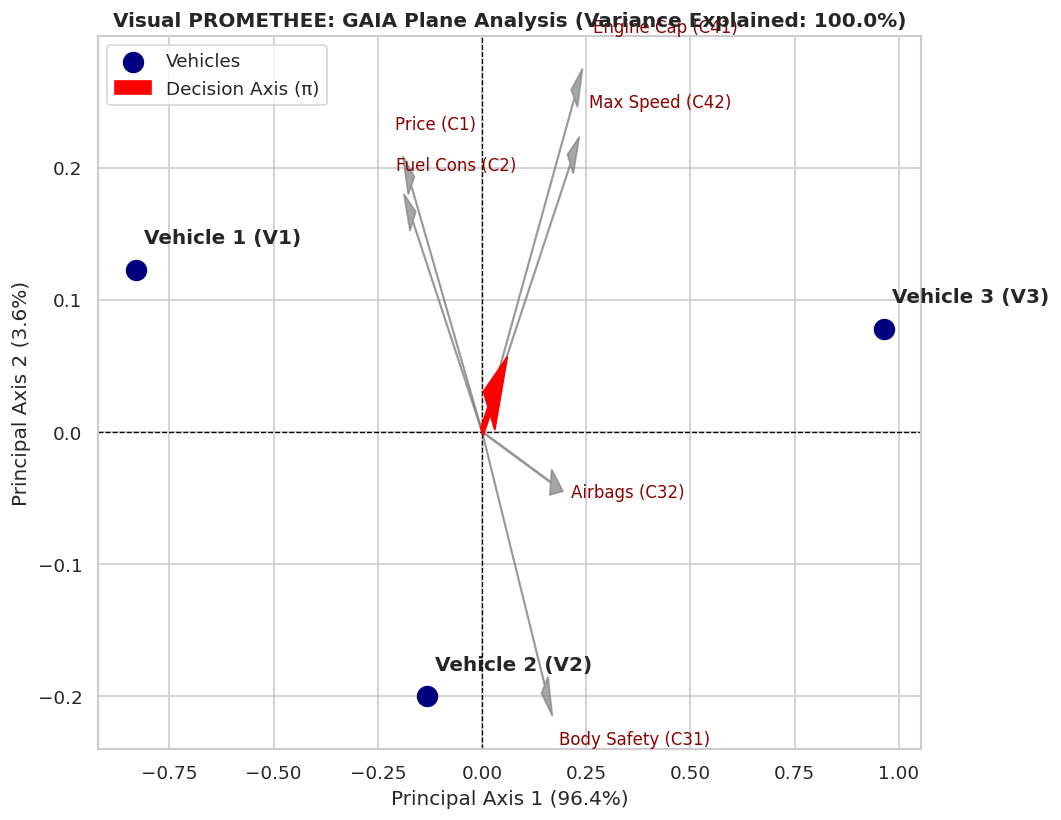

In [14]:
# GAIA performs Principal Component Analysis (PCA) on the unicriterion net flows matrix.
pca = PCA(n_components=2)
gaia_coords = pca.fit_transform(uni_flows)

# Compute projection of criterion axes onto the 2D plane
components = pca.components_  # 2 x n
crit_x = components[0, :]
crit_y = components[1, :]

# Decision Axis pi projection (vector sum of weighted criteria)
pi_vector = np.dot(components, weights_ahp)

plt.figure(figsize=(9, 7))
# 1. Plot Alternatives
plt.scatter(gaia_coords[:, 0], gaia_coords[:, 1], color='navy', s=140, zorder=5, label="Vehicles")
for i, name in enumerate(alternatives):
    plt.annotate(name, (gaia_coords[i, 0] + 0.02, gaia_coords[i, 1] + 0.02), fontweight='bold')

# 2. Plot Criteria Vectors
for j, name in enumerate(criteria):
    plt.arrow(0, 0, crit_x[j]*0.5, crit_y[j]*0.5, color='gray', alpha=0.7, head_width=0.02, length_includes_head=True)
    plt.text(crit_x[j]*0.55, crit_y[j]*0.55, name.split(":")[0], color='darkred', fontsize=10)

# 3. Plot Decision Axis pi
plt.arrow(0, 0, pi_vector[0]*0.7, pi_vector[1]*0.7, color='red', width=0.008, head_width=0.04, length_includes_head=True, zorder=6, label="Decision Axis (π)")

plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title(f"Visual PROMETHEE: GAIA Plane Analysis (Variance Explained: {np.sum(pca.explained_variance_ratio_)*100:.1f}%)", fontsize=12, fontweight='bold')
plt.xlabel(f"Principal Axis 1 ({pca.explained_variance_ratio_[0]*100:.1f}%)")
plt.ylabel(f"Principal Axis 2 ({pca.explained_variance_ratio_[1]*100:.1f}%)")
plt.legend(loc="upper left")
plt.tight_layout()
plt.show()

# METHOD 5 - Rank Aggregation (Borda, Copeland, and Mean Rank)


In [15]:
rank_comparison = pd.DataFrame({
    "TOPSIS": df_topsis["TOPSIS Rank"],
    "VIKOR": df_vikor["VIKOR Rank"],
    "ELECTRE": df_electre["ELECTRE Rank"],
    "PROMETHEE II": df_promethee["PROMETHEE II Rank"]
}, index=alternatives)

m_alts = len(alternatives)
n_methods = rank_comparison.shape[1]

# 1. Mean Rank
mean_ranks = rank_comparison.mean(axis=1).values

# 2. Borda Count
borda_scores = np.zeros(m_alts)
for col in rank_comparison.columns:
    for i in range(m_alts):
        borda_scores[i] += (m_alts - rank_comparison[col].iloc[i])
borda_ranks = pd.Series(borda_scores).rank(ascending=False).astype(int).values

# 3. Copeland Tournament Method
copeland_scores = np.zeros(m_alts)
for i in range(m_alts):
    for j in range(m_alts):
        if i == j: continue
        wins = np.sum(rank_comparison.iloc[i].values < rank_comparison.iloc[j].values)
        losses = np.sum(rank_comparison.iloc[i].values > rank_comparison.iloc[j].values)
        if wins > losses:
            copeland_scores[i] += 1
        elif wins < losses:
            copeland_scores[i] -= 1
copeland_ranks = pd.Series(copeland_scores).rank(ascending=False).astype(int).values

df_aggregated = pd.DataFrame({
    "Mean Rank Score": mean_ranks,
    "Borda Score": borda_scores,
    "Borda Rank": borda_ranks,
    "Copeland Score": copeland_scores,
    "Copeland Rank": copeland_ranks
}, index=alternatives)

print("=== RANK AGGREGATION RESULTS ===")
display(df_aggregated)

=== RANK AGGREGATION RESULTS ===


,Mean Rank Score,Borda Score,Borda Rank,Copeland Score,Copeland Rank
Vehicle 1 (V1),3.0000,0.0000,3,-2.0000,3
Vehicle 2 (V2),1.0000,8.0000,1,2.0000,1
Vehicle 3 (V3),2.0000,4.0000,2,0.0000,2


# Methodological Consensus & Spearman Rank Correlation


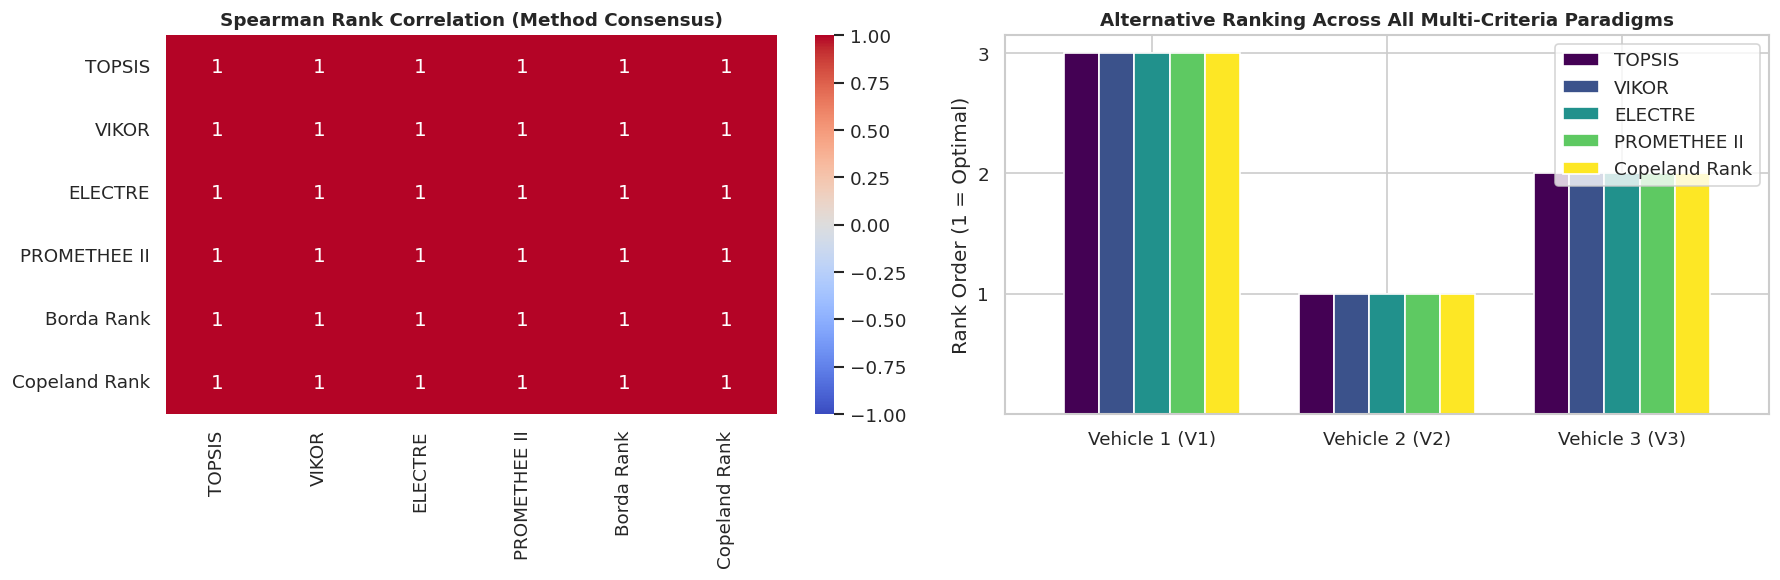

=== FINAL INTEGRATED MCDA BENCHMARK TABLE ===


,TOPSIS,VIKOR,ELECTRE,PROMETHEE II,Borda Rank,Copeland Rank
Vehicle 1 (V1),3,3,3,3,3,3
Vehicle 2 (V2),1,1,1,1,1,1
Vehicle 3 (V3),2,2,2,2,2,2


In [16]:
full_ranks = pd.concat([rank_comparison, df_aggregated[["Borda Rank", "Copeland Rank"]]], axis=1)

# Spearman rank correlation matrix
spearman_corr, _ = stats.spearmanr(full_ranks)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# 1. Heatmap of Methodological Agreement
sns.heatmap(spearman_corr, annot=True, cmap="coolwarm", xticklabels=full_ranks.columns, yticklabels=full_ranks.columns, ax=axes[0], vmin=-1, vmax=1)
axes[0].set_title("Spearman Rank Correlation (Method Consensus)", fontsize=11, fontweight='bold')

# 2. Final Consolidated Ranking Bar Chart
full_ranks[["TOPSIS", "VIKOR", "ELECTRE", "PROMETHEE II", "Copeland Rank"]].plot(kind="bar", ax=axes[1], colormap="viridis", width=0.75)
axes[1].set_title("Alternative Ranking Across All Multi-Criteria Paradigms", fontsize=11, fontweight='bold')
axes[1].set_ylabel("Rank Order (1 = Optimal)")
axes[1].set_yticks([1, 2, 3])
axes[1].set_xticklabels(alternatives, rotation=0)
axes[1].legend(loc="upper right")

plt.tight_layout()
plt.show()

print("=== FINAL INTEGRATED MCDA BENCHMARK TABLE ===")
display(full_ranks)